#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

#### Load And Clean

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print("Churn rate:", df['Churn'].mean().round(3))

Churn rate: 0.265


#### Feature Engineering

In [3]:
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['IsNewCustomer']   = (df['tenure'] < 12).astype(int)
df['HasMultiServices'] = (
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int)
)
print("New features added. Shape:", df.shape)

New features added. Shape: (7043, 23)


#### Define Columns & Build Preprocessor

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'ChargesPerMonth', 'HasMultiServices']
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesPerMonth', 'HasMultiServices']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Train/Test Split

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves 73/27 ratio in both splits
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train size: (5634, 22) | Test size: (1409, 22)
Train churn rate: 0.265
Test churn rate: 0.265


#### Logistic Regression Baseline

In [6]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])
lr_pipe.fit(X_train, y_train)
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_probs)
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(classification_report(y_test, lr_pipe.predict(X_test),
      target_names=['No Churn', 'Churn']))

Logistic Regression AUC: 0.8460
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



#### XGBoost Main Model

In [7]:
xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=3,       # 73/27 ≈ 3x weight for minority class
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    ))
])
xgb_pipe.fit(X_train, y_train)
xgb_probs = xgb_pipe.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost AUC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pipe.predict(X_test),
      target_names=['No Churn', 'Churn']))

XGBoost AUC: 0.8384
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



#### Confusion Matrix

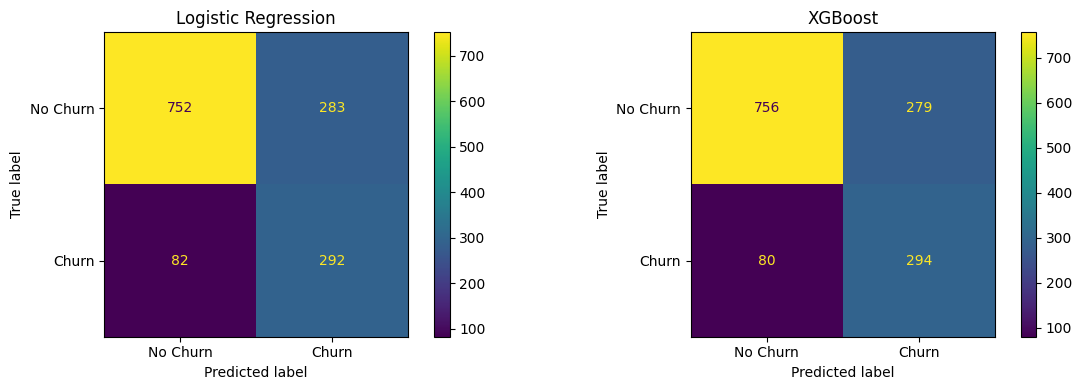

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(
    lr_pipe, X_test, y_test,
    display_labels=['No Churn', 'Churn'], ax=axes[0])
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_estimator(
    xgb_pipe, X_test, y_test,
    display_labels=['No Churn', 'Churn'], ax=axes[1])
axes[1].set_title('XGBoost')
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150)
plt.show()

#### ROC Curve Comparison

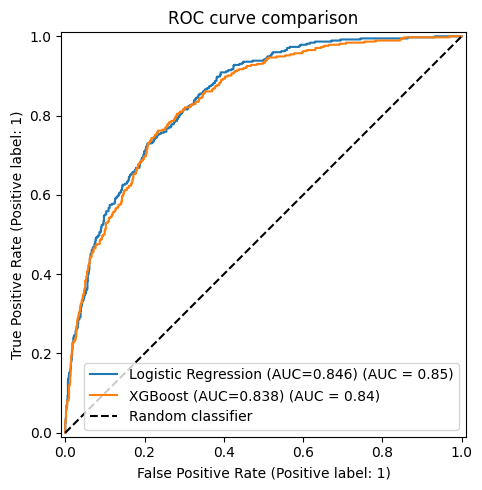

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(lr_pipe, X_test, y_test,
    ax=ax, name=f'Logistic Regression (AUC={lr_auc:.3f})')
RocCurveDisplay.from_estimator(xgb_pipe, X_test, y_test,
    ax=ax, name=f'XGBoost (AUC={xgb_auc:.3f})')
ax.set_title('ROC curve comparison')
ax.plot([0,1],[0,1],'k--', label='Random classifier')
ax.legend()
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150)
plt.show()

#### SHAP Global Feature Importance

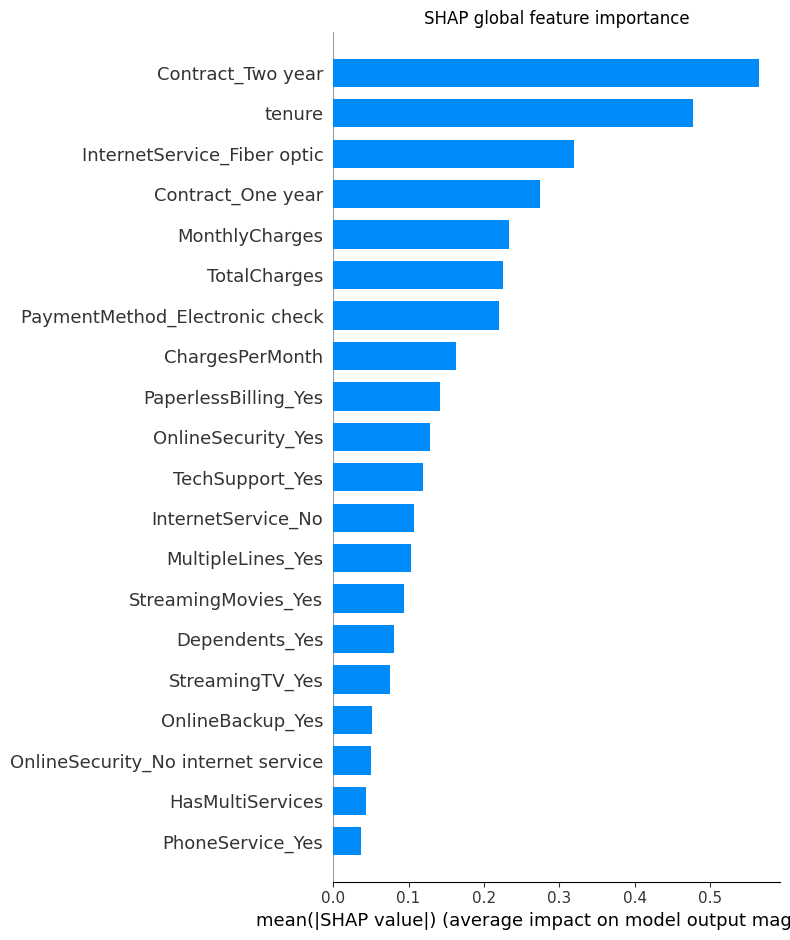

In [10]:
X_test_t  = xgb_pipe[:-1].transform(X_test)
explainer  = shap.TreeExplainer(xgb_pipe['model'])
shap_vals  = explainer.shap_values(X_test_t)

# Get feature names after one-hot encoding
ohe_features = xgb_pipe['prep'].named_transformers_['cat']\
                    .get_feature_names_out(cat_cols).tolist()
all_features = num_cols + ohe_features

# Bar plot — global importance
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_vals, X_test_t,
                  feature_names=all_features,
                  plot_type='bar', show=False)
plt.title('SHAP global feature importance')
plt.tight_layout()
plt.savefig('../data/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

#### SHAP Beeswarm Plot

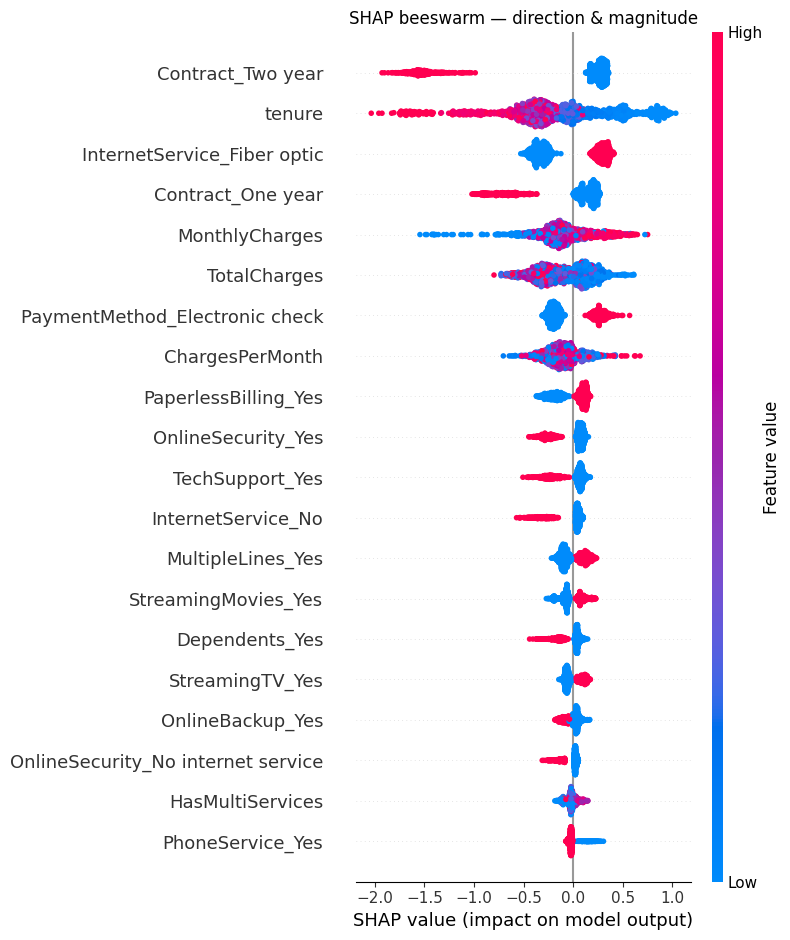

In [11]:
plt.figure(figsize=(8, 8))
shap.summary_plot(shap_vals, X_test_t,
                  feature_names=all_features, show=False)
plt.title('SHAP beeswarm — direction & magnitude')
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

#### SHAP Waterfall For One Customer

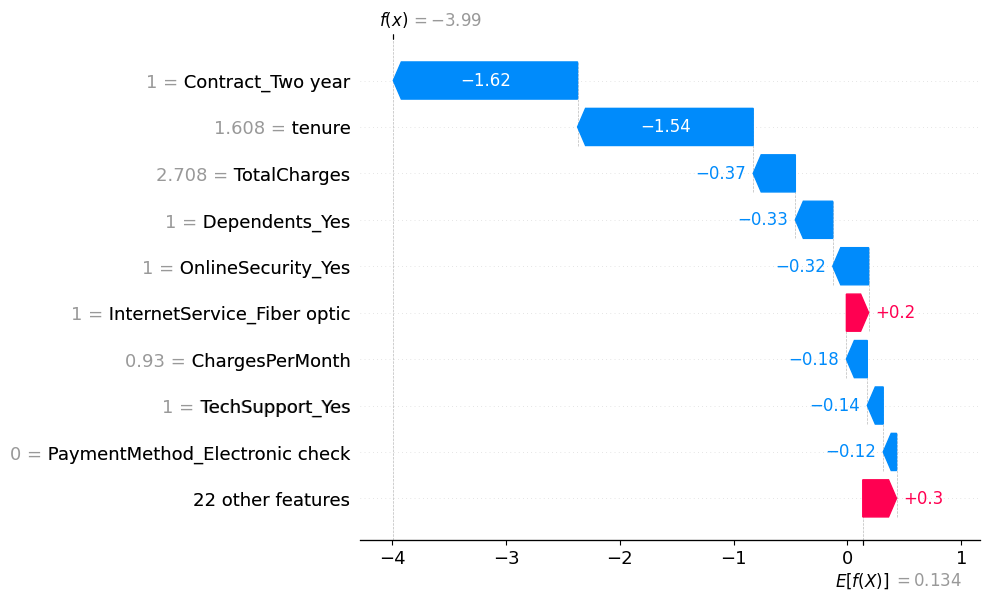

In [12]:
idx = 0  # change this to inspect any customer
shap.waterfall_plot(shap.Explanation(
    values=shap_vals[idx],
    base_values=explainer.expected_value,
    data=X_test_t[idx],
    feature_names=all_features
))

#### Save Models & Artifacts

In [15]:
joblib.dump(xgb_pipe, '../models/churn_model.pkl')
joblib.dump(explainer, '../models/shap_explainer.pkl')

import json
with open('../models/feature_names.json', 'w') as f:
    json.dump({'num': num_cols, 'cat': cat_cols,
               'all': all_features}, f)

print("Model saved to models/churn_model.pkl")
print("Explainer saved to models/shap_explainer.pkl")

Model saved to models/churn_model.pkl
Explainer saved to models/shap_explainer.pkl
